
# Accenture Project Overview

## Challenge Objective

Analyse pollutant levels in European cities using 10 years of annual air quality statistics (2015-2024) published by the European Environment Agency (EEA).
The ultimate goal of the full project is to predict future Air Quality Index (AQI) values or flag regulatory limit exceedances using machine learning.

## Dataset

- Source: EEA Annual Air Quality Statistics (e-Reporting)
- Time range: 2015 to 2024, one CSV file per year
- Pollutants covered: NO2, PM10, PM2.5, O3
- Geography: Europe-wide monitoring stations with a focus on Italy
- One row = one monitoring station x one statistical summary x one year

## Notebook Roadmap

| Part | Title | Goal |
|------|-------|------|
| 1 | Environment and Data Loading | Load all 10 CSVs into one DataFrame |
| 2 | Data Quality Assessment | Understand missingness, coverage, validation flags |
| 3 | Univariate EDA | Distribution of pollution levels per pollutant |
| 4 | Temporal EDA | Trends over 2015-2024 |
| 5 | Spatial EDA | Geographic and station-type patterns |
| 6 | Correlation and Relationships | Inter-pollutant correlations |
| 7 | Key Findings and Next Steps | Business insights and cleaning agenda |

## Note on Data Leakage

This notebook only performs exploratory analysis. No model is trained here.
Columns that encode reporting-time metadata (Data Coverage, Verification, Calculation Time) will not be used as model features in later steps.
This will be flagged explicitly each time these columns appear.

---

---
# Environment and Data Loading


10 separate CSV files, one per year between 2015-2024, loaded into a single DataFrame. After loading, we make the first inspection to understand the structure of data.

## Importing Libraries

In [106]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Force white background and light gray grid globally for PyCharm
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'text.color': 'black',
    'grid.color': '#CCCCCC',
    'grid.alpha': 0.5
})
sns.set_style('whitegrid', rc={'figure.facecolor': 'white', 'axes.facecolor': 'white', 'grid.color': '#CCCCCC'})


# Global variables
focus_pollutants = ["NO2", "PM10", "PM2.5", "O3"]
secondary_pollutants = ["SO2", "CO", "C6H6"]
all_pollutants = focus_pollutants + secondary_pollutants

aggregation_id = "P1Y-day-per50"

print("Libraries loaded")

Libraries loaded


## Combining CSV

In [107]:
DATA = "2015-2024"
years = range(2015, 2025)

frames = []
for year in years:
    file_path = os.path.join(DATA, f"DataExtract{year}.csv")
    df_year = pd.read_csv(file_path, low_memory=False)
    frames.append(df_year)
    print(f"{year}: {df_year.shape[0]:,} rows")

df = pd.concat(frames, ignore_index=True)
print(f"\nCombined DataFrame: {df.shape[0]:,} rows, {df.shape[1]} columns")

DATA_DIR = '2015-2024'
years = list(range(2015, 2025))

2015: 36,550 rows
2016: 38,330 rows
2017: 39,012 rows
2018: 48,394 rows
2019: 50,045 rows
2020: 50,029 rows
2021: 51,287 rows
2022: 53,016 rows
2023: 50,953 rows
2024: 50,865 rows

Combined DataFrame: 468,481 rows, 27 columns


## Country comparison dataset

In [108]:
comparison = "country_comparison"
comparison_folders = ["FR", "CH", "AT"]

df_compare_list = []

for code in comparison_folders:
    folder_path = os.path.join(comparison, code)

    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)
        df_temp = pd.read_csv(file_path, low_memory=False)
        df_compare_list.append(df_temp)
    print(f"{code} loaded.")

# Build focused dataframe directly — no need to store the raw version
df_compare_focus = pd.concat(df_compare_list, ignore_index=True)
df_compare_focus = df_compare_focus[
    (df_compare_focus["Data Aggregation Process Id"] == aggregation_id) &
    (df_compare_focus["Air Pollutant"].isin(focus_pollutants))].copy()

print("df_compare_focus rows:", f"{len(df_compare_focus):,}")
print(df_compare_focus["Country"].value_counts())


FR loaded.
CH loaded.
AT loaded.
df_compare_focus rows: 18,989
Country
France         13195
Austria         4804
Switzerland      990
Name: count, dtype: int64


## Look at the Raw Data

In [109]:
df.head(3)

,Country,Air Quality Network,Air Quality Network Name,Air Quality Station EoI Code,Air Quality Station Name,Sampling Point Id,Air Pollutant,Air Pollutant Description,Data Aggregation Process Id,Data Aggregation Process,...,Longitude,Latitude,Altitude,City,City Code,City Population,Source Of Data Flow,Calculation Time,Link to raw data (only E1a/validated data from AQ e-Reporting),Observation Frequency
0,Italy,NET.IT082A,Rete di Rilevamento della Qualit� dell'Aria de...,IT1034A,MEDA,SPO.IT1034A_5_BETA_1998-02-05_00:00:00,PM10,Particulate matter < 10 µm (aerosol),P1Y-day-per50,1 year 50 %ile of daily values in a year,...,9.1569,45.6608,221.0,Milano (greater city) ...,IT002K1 ...,3622641.0,E1a/validated data AQ e-Reporting,17/02/2026 23:01:33,https://eeadmz1batchservice02.blob.core.window...,day
1,Italy,NET.IT082A,Rete di Rilevamento della Qualit� dell'Aria de...,IT0480A,SESTO S.GIOVANNI,SPO.IT0480A_8_chemi_1974-11-01_00:00:00,NO2,Nitrogen dioxide (air),P1Y-day-min,1 year day min,...,9.2364,45.5339,137.0,Milano (greater city) ...,IT002K1 ...,3622641.0,E1a/validated data AQ e-Reporting,17/02/2026 23:01:25,https://eeadmz1batchservice02.blob.core.window...,hour
2,Italy,NET.IT082A,Rete di Rilevamento della Qualit� dell'Aria de...,IT0480A,SESTO S.GIOVANNI,SPO.IT0480A_8_chemi_1974-11-01_00:00:00,NO2,Nitrogen dioxide (air),P1Y-day-per50,1 year 50 %ile of daily values in a year,...,9.2364,45.5339,137.0,Milano (greater city) ...,IT002K1 ...,3622641.0,E1a/validated data AQ e-Reporting,17/02/2026 23:01:33,https://eeadmz1batchservice02.blob.core.window...,hour


In [110]:
# Column names and data types
print(df.dtypes)

Country                                                            object
Air Quality Network                                                object
Air Quality Network Name                                           object
Air Quality Station EoI Code                                       object
Air Quality Station Name                                           object
Sampling Point Id                                                  object
Air Pollutant                                                      object
Air Pollutant Description                                          object
Data Aggregation Process Id                                        object
Data Aggregation Process                                           object
Year                                                                int64
Air Pollution Level                                               float64
Unit Of Air Pollution Level                                        object
Data Coverage                         

In [111]:
# Basic descriptive statistics
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Country,468481,1,Italy,468481,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Air Quality Network,468481,74,NET.IT112A,38900,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Air Quality Network Name,468481,74,Regione Lazio,38900,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Air Quality Station EoI Code,468481,796,IT1993A,1678,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Air Quality Station Name,468481,793,CENMO1,1678,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sampling Point Id,468481,5446,SPO.IT1203A_7_UV-P_1999-01-20_00:00:00,288,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Air Pollutant,468481,38,NO2,116548,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Air Pollutant Description,468481,38,Nitrogen dioxide (air),116548,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Data Aggregation Process Id,468481,59,P1Y,36388,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Data Aggregation Process,468481,58,Annual mean / 1 calendar year,36388,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
# Data Quality Assessment

*Why this step?*

Before drawing any conclusions, we need to understand how complete and trustworthy the data is.
Data quality problems — missing values, incomplete year coverage, unvalidated entries — can produce misleading charts and wrong conclusions if ignored.
This section answers: can we trust this data, and where are the gaps?

Note on leakage: Data Coverage, Verification, and Calculation Time are reporting-time metadata.
They would not be available at prediction time, so they must never be used as model features.
We study them here only to assess data quality.

## Missing Values

In [112]:
# Count missing values per column
missing_count = df.isnull().sum()
miss_percentage = (missing_count / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing_count, 'Missing %': miss_percentage})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('Columns with missing values:')
print(missing_df)
missing_df.to_csv("images/missing_df.csv")

Columns with missing values:
                                                    Missing Count  Missing %
City                                                       290697      62.05
City Population                                            290697      62.05
City Code                                                  290697      62.05
Air Pollution Level                                          4629       0.99
Observation Frequency                                        1564       0.33
Link to raw data (only E1a/validated data from ...            897       0.19
Altitude                                                      149       0.03


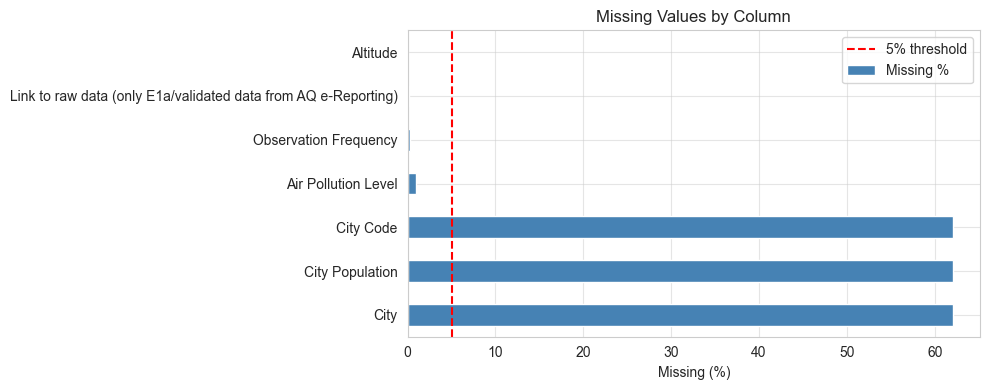

In [113]:
# Bar chart of missing values
missing_df['Missing %'].plot(kind='barh', figsize=(10, 4), color='steelblue')
plt.xlabel('Missing (%)')
plt.title('Missing Values by Column')
plt.axvline(5, color='red', linestyle='--', label='5% threshold')
plt.legend()
plt.tight_layout()
plt.savefig("images/missing_value_barchart.png", dpi=300)
plt.show()

City is missing for ~62% of records. For Italy, we enrich station metadata by spatially joining station coordinates (lat/lon) with ISTAT ‘comuni’ boundaries using GeoPandas. This assigns each station to a municipality (Comune), which we use as City.

## Handling Missing Cities

In [114]:
# Handling Missing cities
import geopandas as gpd

comuni = gpd.read_file("data_boundaries/comuni_2024/comuni_2024.shp")
print(comuni.crs)
print(comuni.columns.tolist())

# Convert comuni to WGS84 lat/lon to correctly match station coordinates
comuni = comuni.to_crs("EPSG:4326")
print("New CRS:", comuni.crs)

EPSG:32632
['COD_RIP', 'COD_REG', 'COD_PROV', 'COD_CM', 'COD_UTS', 'PRO_COM', 'PRO_COM_T', 'COMUNE', 'COMUNE_A', 'CC_UTS', 'Shape_Leng', 'Shape_Area', 'geometry']
New CRS: EPSG:4326


In [115]:
# Keep Italy rows with valid coordinates
df_it = df[df["Country"] == "Italy"].copy()
df_it = df_it.dropna(subset=["Longitude", "Latitude"])

# Create geometry column from lon/lat
gdf_stations = gpd.GeoDataFrame(
    df_it,
    geometry=gpd.points_from_xy(df_it["Longitude"], df_it["Latitude"]),
    crs="EPSG:4326"
)

print("Station CRS:", gdf_stations.crs)
print("Number of Italy station rows:", len(gdf_stations))

Station CRS: EPSG:4326
Number of Italy station rows: 468481


In [116]:
joined = gpd.sjoin(
    gdf_stations[["Air Quality Station EoI Code", "geometry"]],
    comuni[["COMUNE", "PRO_COM", "geometry"]],
    how="left",
    predicate="within"
)

print("Joined rows:", len(joined))
print("Share of stations matched to a comune:",
      round(joined["COMUNE"].notna().mean() * 100, 2), "%")

joined.head(5).to_csv("images/joined_comune.csv")
joined.head(5)

Joined rows: 468481
Share of stations matched to a comune: 99.42 %


,Air Quality Station EoI Code,geometry,index_right,COMUNE,PRO_COM
0,IT1034A,POINT (9.1569 45.6608),7762.0,Meda,108030.0
1,IT0480A,POINT (9.2364 45.5339),2258.0,Sesto San Giovanni,15209.0
2,IT0480A,POINT (9.2364 45.5339),2258.0,Sesto San Giovanni,15209.0
3,IT0705A,POINT (9.1958 45.4628),2218.0,Milano,15146.0
4,IT1743A,POINT (9.2744 45.5811),7765.0,Monza,108033.0


In [117]:
# Build mapping from station code to comune name
station_to_city = (
    joined.dropna(subset=["COMUNE"])
    .groupby("Air Quality Station EoI Code")["COMUNE"]
    .agg(lambda s: s.mode().iloc[0])
)

print("Stations with assigned comune:", len(station_to_city))

Stations with assigned comune: 792


In [118]:
# Clean City column first
df["City"] = df["City"].astype("string").str.strip()
df.loc[df["City"] == "", "City"] = pd.NA

it_mask = df["Country"] == "Italy"

before = df.loc[it_mask, "City"].isna().mean() * 100

df.loc[it_mask, "City"] = df.loc[it_mask, "City"].fillna(
    df.loc[it_mask, "Air Quality Station EoI Code"].map(station_to_city)
)

after = df.loc[it_mask, "City"].isna().mean() * 100

print(f"Italy missing City — before: {before:.2f}% | after: {after:.2f}%")
print("Unique cities in full df:", df["City"].nunique())

Italy missing City — before: 62.05% | after: 0.37%
Unique cities in full df: 461


## Data Coverage

The Data Coverage column tells us what fraction of the year a station was actually measuring.
A station with 40% coverage was only active for about 5 months — its annual summary is less reliable.
The EEA recommends at least 75% coverage for a statistic to be considered valid.

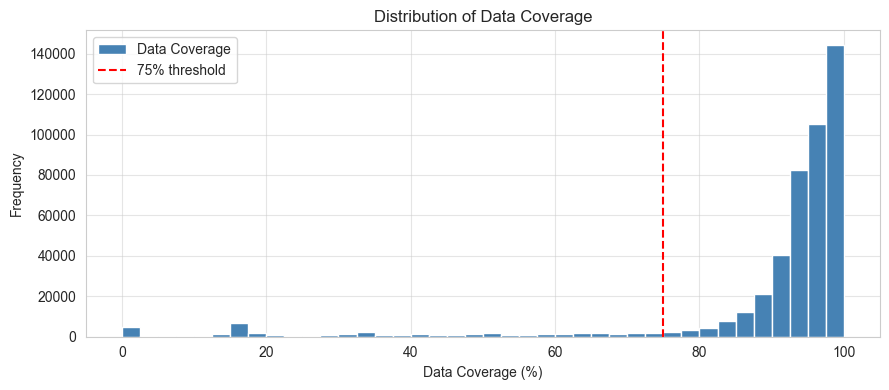

Coverage >= 75%: 423352 rows (90.4%)
Coverage <  75%: 45129 rows (9.6%)


In [119]:
# Distribution of Data Coverage
df['Data Coverage'].dropna().plot(kind='hist', bins=40, figsize=(9, 4), color='steelblue', edgecolor='white')
plt.axvline(75, color='red', linestyle='--', label='75% threshold')
plt.xlabel('Data Coverage (%)')
plt.title('Distribution of Data Coverage')
plt.legend()
plt.tight_layout()
plt.savefig("images/distribution_of_data_coverage.png", dpi=300)
plt.show()

above_75 = (df['Data Coverage'] >= 75).sum()
below_75 = (df['Data Coverage'] < 75).sum()
print(f'Coverage >= 75%: {above_75:} rows ({above_75 / len(df) * 100:.1f}%)')
print(f'Coverage <  75%: {below_75:} rows ({below_75 / len(df) * 100:.1f}%)')

## Verification Flags

The Verification column records whether data was officially validated by the reporting authority.
Value 1 means validated. Anything else should be treated with caution.

Verification
1    463913
3      4568
Name: count, dtype: int64


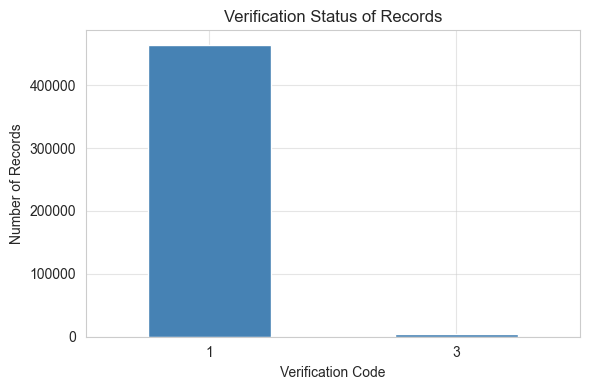

In [120]:
verif_counts = df['Verification'].value_counts(dropna=False)
print(verif_counts)

verif_counts.plot(kind='bar', figsize=(6, 4), color='steelblue', edgecolor='white')
plt.title('Verification Status of Records')
plt.xlabel('Verification Code')
plt.ylabel('Number of Records')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("images/verification_status.png", dpi=300)
plt.show()

## Aggregation Process Breakdown

Each row does not represent a direct sensor reading. It represents a statistical summary of an entire year.
Different rows for the same station and year represent different statistics:
annual median, annual maximum, annual 99th percentile, and so on.

This matters a lot: mixing different aggregation types in one analysis would be like comparing apples and oranges.
For the EDA sections that follow, we will consistently use the annual median (P1Y-day-per50),
which is the 50th percentile of daily values over a full year.

Data Aggregation Process
Annual mean / 1 calendar year                                                    36388
1 year day min                                                                   34876
1 year day max                                                                   34876
1 year 50 %ile of daily values in a year                                         34837
1 year hour max                                                                  22716
1 year hour min                                                                  22716
1 year 50 percentile                                                             22687
1 year 99 percentile of daily means (P1D) or .../aq/primaryObservation/day       21308
3 subsequent calendar years mean                                                 21087
1 year 95.07 percentile of daily means (P1D) or .../aq/primaryObservation/day    17960
1 year day exceed 50                                                             15857
1 year 99.97 %ile 

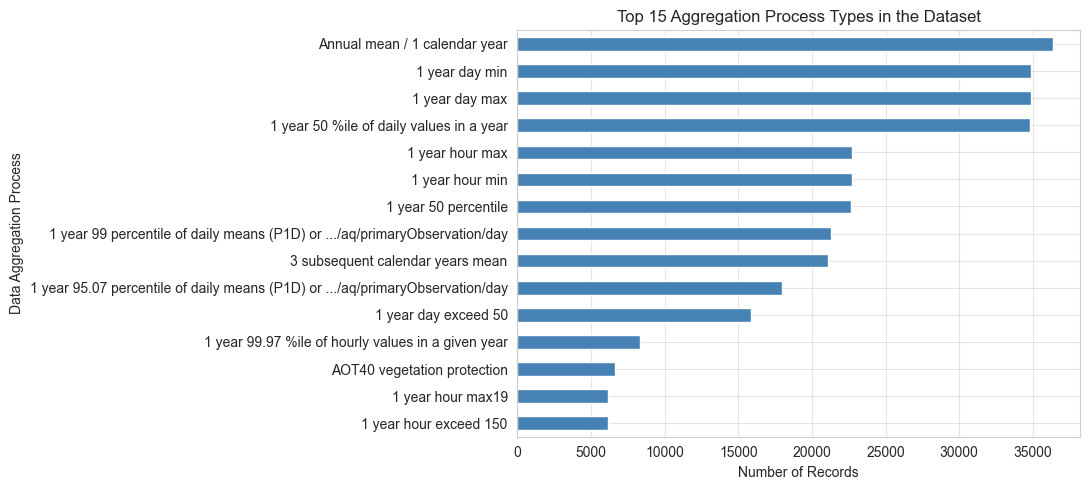

In [121]:
agg_counts = df['Data Aggregation Process'].value_counts().head(15)
agg_counts.to_csv("images/top_15_aggregation_processes.csv")
print(agg_counts.to_string())

agg_counts.plot(kind='barh', figsize=(11, 5), color='steelblue')
plt.xlabel('Number of Records')
plt.title('Top 15 Aggregation Process Types in the Dataset')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("images/top_15_aggregation_processes.png", dpi=300)
plt.show()

## Duplicate Check

In [122]:
# Exact duplicate rows
n_dup = df.duplicated().sum()
print(f'Exact duplicate rows: {n_dup:,} ({n_dup / len(df) * 100:.2f}%)')

# Logical duplicates: same station + pollutant + aggregation type + year
key_cols = ['Air Quality Station EoI Code', 'Air Pollutant', 'Data Aggregation Process', 'Year']
n_logical = df.duplicated(subset=key_cols).sum()
print(f'Logical duplicate rows (same station, pollutant, aggregation, year): {n_logical:,}')

Exact duplicate rows: 0 (0.00%)
Logical duplicate rows (same station, pollutant, aggregation, year): 4,565


## Summary

Key data quality observations — these will inform the cleaning phase (Step 3 of the challenge):

- Which columns have missing values and at what proportion
- What fraction of rows have low data coverage (below 75%) — these produce less reliable annual statistics
- How many records are unverified — these may need to be excluded from modeling
- The dataset contains multiple aggregation types per station — analysis must group by type or fix one type

---

---
# EDA: Pollutant Distributions

*Why this step?*

Before comparing across time or geography, we need to understand what each pollutant looks like on its own.
Univariate analysis answers:

- Which pollutants are most commonly measured in the dataset?
- What is the typical range of pollution levels across European stations?
- Are there extreme outliers? Is the distribution skewed?

From here onward we work with annual median values only (aggregation code P1Y-day-per50).
This gives us one representative number per station per year, making comparisons fair and consistent.

We are still on raw data — no quality filters applied. What you see includes all coverage levels and verification statuses.

## Which pollutants are present?

Air Pollutant
NO2                              116548
O3                                96952
PM10                              71666
SO2                               46146
CO                                27382
PM2.5                             27332
NOX as NO2                        17314
C6H6                              16287
NO                                13008
BaP in PM10                        5651
Cd in PM10                         4688
As in PM10                         4665
Ni in PM10                         4450
Pb in PM10                         4448
C6H5-CH3                           3029
o-C6H4-(CH3)2                      2869
C6H5-C2H5                          1855
m,p-C6H4(CH3)2                     1784
H2S                                 371
C6H4-(CH3)2                         236
CH4                                 217
THC (NM)                            209
m-C6H4-(CH3)2                       175
p-C6H4(CH3)2                        175
Benzo(j)fluoranthene in PM

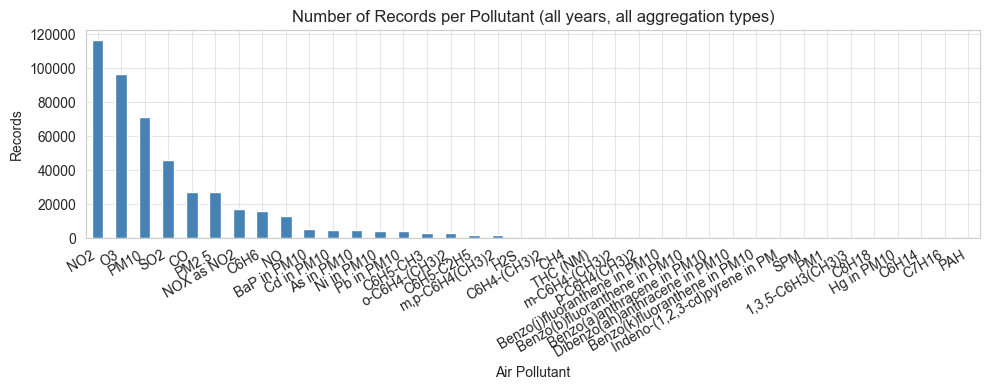

In [123]:
pollutant_counts = df['Air Pollutant'].value_counts()
pollutant_counts.to_csv("images/pollutant_counts.csv")
print(pollutant_counts.to_string())

pollutant_counts.plot(kind='bar', figsize=(10, 4), color='steelblue', edgecolor='white')
plt.title('Number of Records per Pollutant (all years, all aggregation types)')
plt.ylabel('Records')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig("images/pollutant_counts.png", dpi=300)
plt.show()

The dataset contains a large number of pollutants, but their observation frequency varies widely.

For the main analysis we focus on the four most consistently monitored pollutants (NO2, PM10, PM2.5, O3).

However, three additional pollutants (SO2, CO, C6H6) are included to enrich the interpretation of emission sources.

## Focused DataFrame

In [124]:
# Create df_focus: EDA subset (annual median-of-daily values + main pollutants)
df_focus = df[
    (df["Data Aggregation Process Id"] == aggregation_id) &
    (df["Air Pollutant"].isin(focus_pollutants))].copy()

# Create df_extended: includes both main and secondary pollutants
df_extended = df[
    (df["Data Aggregation Process Id"] == aggregation_id) &
    (df["Air Pollutant"].isin(all_pollutants))
]

print("df_focus rows:", f"{len(df_focus):,}")
print("Countries in focus:", df_focus["Country"].nunique())
print(df_focus["Country"].value_counts())

print("\nPollutant summary (Air Pollution Level):")
print(df_focus.groupby("Air Pollutant")["Air Pollution Level"].describe().round(2))

df_focus rows: 17,010
Countries in focus: 1
Country
Italy    17010
Name: count, dtype: int64

Pollutant summary (Air Pollution Level):
                count   mean    std    min    25%    50%    75%     max
Air Pollutant                                                          
NO2            6102.0  18.42  11.10   0.42  10.08  17.00  24.06   79.12
O3             3333.0  58.14  13.07  14.17  48.67  56.54  66.64  107.69
PM10           4880.0  20.05   5.43   1.00  16.60  20.00  23.50   41.00
PM2.5          2586.0  11.90   3.73   1.00   9.30  11.55  14.00   27.60


In [125]:
# Checking unit of air pollution for chosen pollutants
pollutant_units = (df_extended[['Air Pollutant', 'Unit Of Air Pollution Level']]
                   .drop_duplicates())            # remove duplicates)

display(pollutant_units)
pollutant_units.to_csv("images/pollutant_units.csv")

,Air Pollutant,Unit Of Air Pollution Level
0,PM10,ug/m3
2,NO2,ug/m3
4,SO2,ug/m3
8,CO,mg/m3
44,PM2.5,ug/m3
398,O3,ug/m3
474,C6H6,ug/m3


## Histograms per pollutant

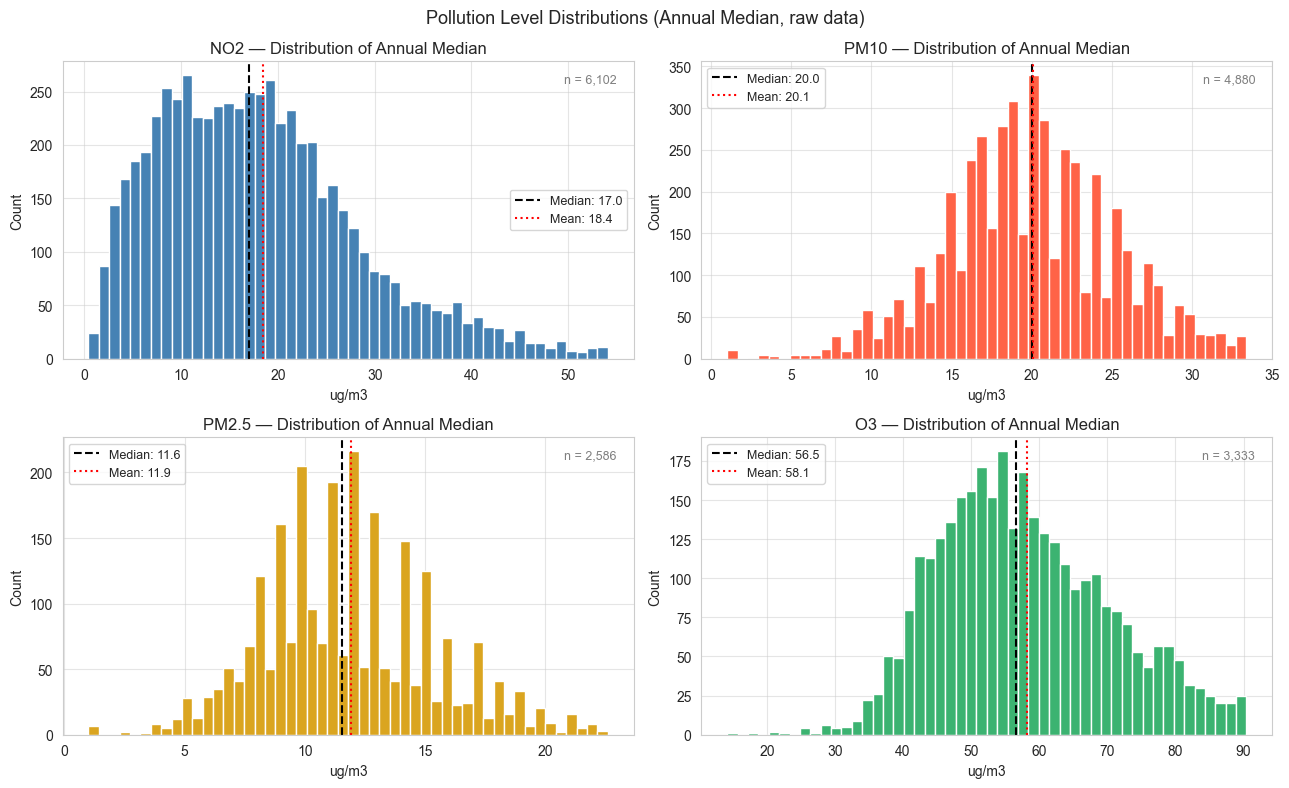

In [133]:
# Histograms — one per pollutant

colors = ['steelblue', 'tomato', 'goldenrod', 'mediumseagreen']

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, (pollutant, color) in enumerate(zip(focus_pollutants, colors)):
    data = df_focus[df_focus['Air Pollutant'] == pollutant]['Air Pollution Level'].dropna()

    # Cap at 99th percentile so outliers do not compress the visible range
    cap = data.quantile(0.99)
    data_capped = data[data <= cap]

    axes[i].hist(data_capped, bins=50, color=color, edgecolor='white')
    axes[i].axvline(data.median(), color='black', linestyle='--', label=f'Median: {data.median():.1f}')
    axes[i].axvline(data.mean(), color='red', linestyle=':', label=f'Mean: {data.mean():.1f}')
    axes[i].set_title(f'{pollutant} — Distribution of Annual Median')
    axes[i].set_xlabel('ug/m3')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=9)
    axes[i].text(0.97, 0.93, f'n = {len(data):,}', transform=axes[i].transAxes,
                 ha='right', fontsize=9, color='grey')

plt.suptitle('Pollution Level Distributions (Annual Median, raw data)', fontsize=13)
plt.tight_layout()
plt.savefig("images/pollution_level_distributions.png", dpi=300)
plt.show()

### Extended Pollutant Distributions (Secondary Pollutants)

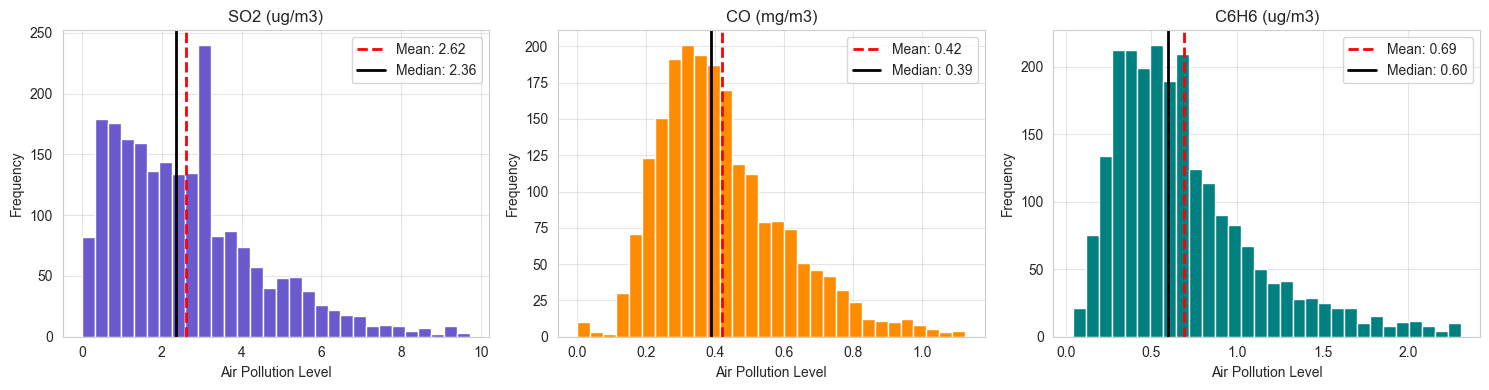

In [127]:
extra_colors = ['slateblue', 'darkorange', 'teal']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, pollutant, color in zip(axes, secondary_pollutants, extra_colors):
    data = df_extended[df_extended["Air Pollutant"] == pollutant]["Air Pollution Level"].dropna()

    cap = data.quantile(0.99)
    data_capped = data[data <= cap]

    # compute statistics
    mean_val = data_capped.mean()
    median_val = data_capped.median()

    ax.hist(data_capped, bins=30, color=color, edgecolor='white')

    # mean and median lines
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f"Mean: {mean_val:.2f}")
    ax.axvline(median_val, color='black', linestyle='-', linewidth=2, label=f"Median: {median_val:.2f}")

    unit = df_extended[df_extended["Air Pollutant"] == pollutant]["Unit Of Air Pollution Level"].dropna().mode()
    unit_text = unit.iloc[0] if not unit.empty else ""
    ax.set_title(f"{pollutant} ({unit_text})")
    ax.set_xlabel("Air Pollution Level")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()
plt.savefig("images/secondary_pollution_level_distributions.png", dpi=300)
plt.show()

## Boxplots

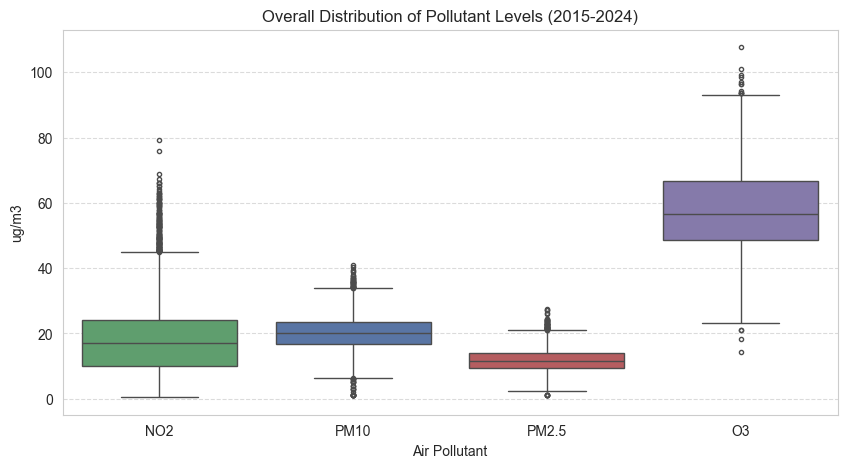

In [128]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df_focus, x='Air Pollutant', y='Air Pollution Level',
            hue='Air Pollutant', legend=False,
            order=focus_pollutants, showfliers=True, flierprops={'marker':'.'},
            palette=['#4c72b0', '#55a868', '#c44e52', '#8172b2'])

plt.title('Overall Distribution of Pollutant Levels (2015-2024)')
plt.ylabel('ug/m3')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("images/overall_pollution_level_distributions.png", dpi=300)
plt.show()

## Conclusion: Business Insight

Key takeaways from the pollutant distributions:

- All distributions are right-skewed. Most stations record moderate levels, but a small number of stations are severe hotspots far above the average.
- The gap between median and mean reveals how much those extreme stations pull the average upward.
- Outliers typically represent high-traffic urban cores or industrial areas — the stations regulators care most about.
- This right skew confirms that in the cleaning step, we will need a strategy for handling extreme values before modeling.

---

---
# EDA: Trends Over 2015-2024

*Why this step?*

Temporal analysis answers the most fundamental policy question: is air quality improving over time?
Three events make this decade interesting:

- COVID-19 lockdowns (2020): traffic and industrial activity nearly stopped — did pollution drop?
- EU Clean Air directives: ongoing regulatory pressure should appear as a gradual downward trend
- Post-COVID rebound (2021-2022): did pollutant levels return once restrictions lifted?

We compute the median pollution level across all stations for each year, which gives a Europe-wide signal.

## Median Polution Level

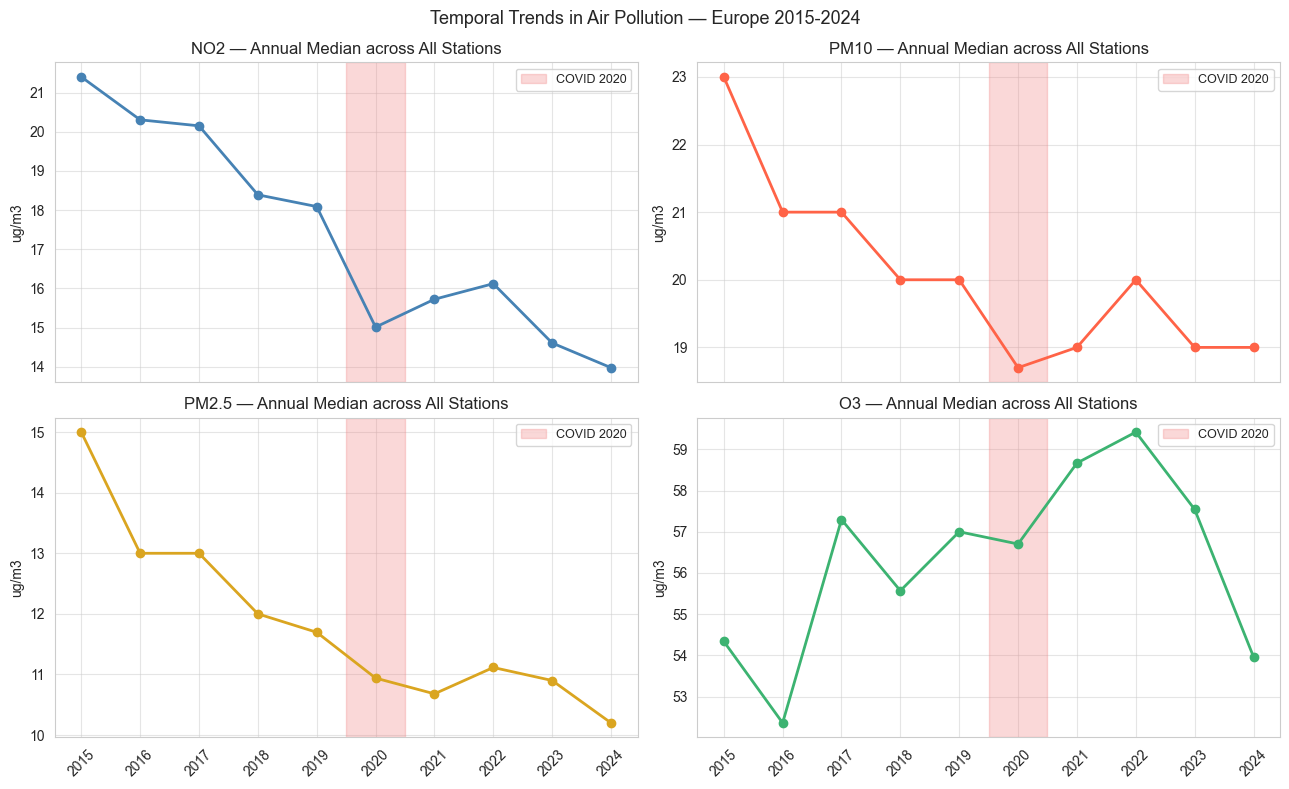

In [129]:
# Median pollution level by year for each pollutant
trend = (
    df_focus
    .groupby(['Year', 'Air Pollutant'])['Air Pollution Level']
    .median()
    .reset_index()
)
trend.columns = ['Year', 'Pollutant', 'Median Level']

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
axes = axes.flatten()

for i, (pollutant, color) in enumerate(zip(focus_pollutants, colors)):
    sub = trend[trend['Pollutant'] == pollutant].sort_values('Year')
    axes[i].plot(sub['Year'], sub['Median Level'], marker='o', color=color, linewidth=2)
    axes[i].axvspan(2019.5, 2020.5, color='lightcoral', alpha=0.3, label='COVID 2020')
    axes[i].set_title(f'{pollutant} — Annual Median across All Stations')
    axes[i].set_ylabel('ug/m3')
    axes[i].set_xticks(sub['Year'].unique())
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(fontsize=9)

plt.suptitle('Temporal Trends in Air Pollution — Europe 2015-2024', fontsize=13)
plt.tight_layout()
plt.savefig("images/temporal_trend_distributions.png", dpi=300)
plt.show()

## Yearly Percentage Change

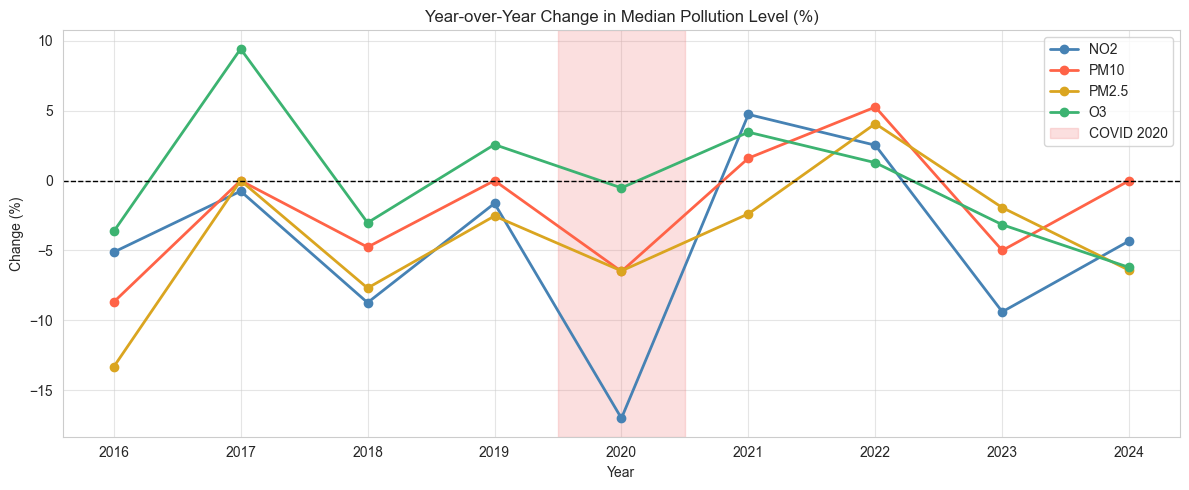

Pollutant    NO2    O3  PM10  PM2.5
Year                               
2015         NaN   NaN   NaN    NaN
2016       -5.12 -3.64 -8.70 -13.33
2017       -0.76  9.43  0.00   0.00
2018       -8.74 -3.02 -4.76  -7.69
2019       -1.63  2.58  0.00  -2.53
2020      -17.01 -0.52 -6.50  -6.46
2021        4.74  3.46  1.60  -2.38
2022        2.53  1.28  5.26   4.07
2023       -9.39 -3.16 -5.00  -1.93
2024       -4.32 -6.22  0.00  -6.42


In [130]:
YoY = trend.copy()
YoY['YoY Change %'] = YoY.groupby('Pollutant')['Median Level'].pct_change() * 100

fig, ax = plt.subplots(figsize=(12, 5))
for pollutant, color in zip(focus_pollutants, colors):
    sub = YoY[(YoY['Pollutant'] == pollutant) & YoY['YoY Change %'].notna()]
    ax.plot(sub['Year'], sub['YoY Change %'], marker='o', label=pollutant, color=color, linewidth=2)

ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.axvspan(2019.5, 2020.5, color='lightcoral', alpha=0.25, label='COVID 2020')
ax.set_title('Year-over-Year Change in Median Pollution Level (%)')
ax.set_ylabel('Change (%)')
ax.set_xlabel('Year')
ax.legend()
plt.tight_layout()
plt.savefig("images/YoY_change_in_median.png", dpi=300)
plt.show()

# Print the table
(YoY.pivot(index='Year', columns='Pollutant', values='YoY Change %').round(2)
            .to_csv('images/YoY_change_in_median.csv'))
print(YoY.pivot(index='Year', columns='Pollutant', values='YoY Change %').round(2))

Since there is no 2014 data, it's impossible to calculate 2015 change

## Secondary Pollutant Trends

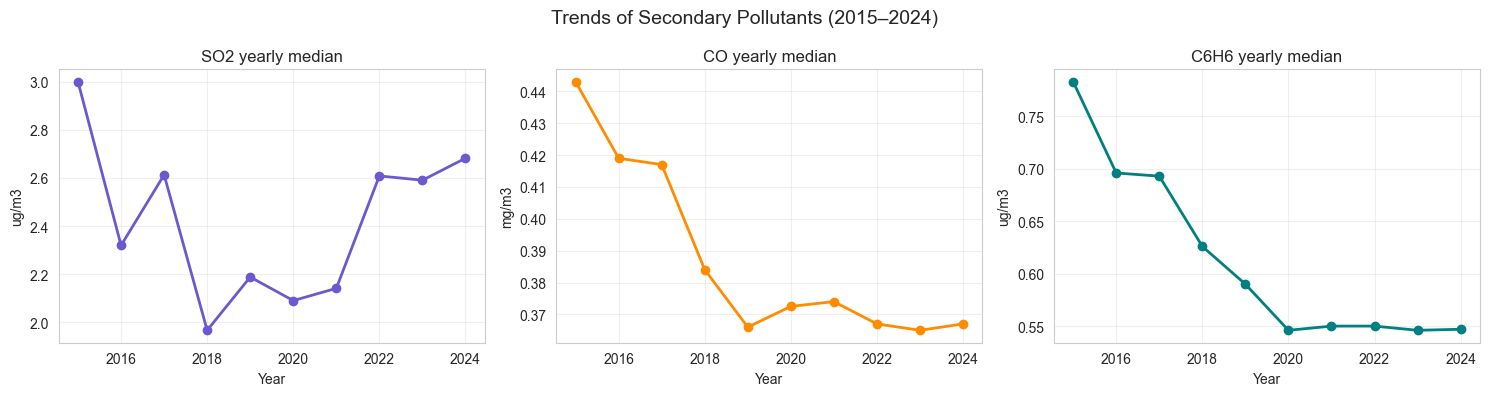

Air Pollutant
C6H6    0.60
CO      0.39
SO2     2.38
Name: Air Pollution Level, dtype: float64

In [131]:
colors = {
    "SO2": "slateblue",
    "CO": "darkorange",
    "C6H6": "teal"
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

for ax, pollutant in zip(axes, secondary_pollutants):

    subset = secondary_trend[
        secondary_trend["Air Pollutant"] == pollutant
    ].sort_values("Year")

    ax.plot(
        subset["Year"],
        subset["Air Pollution Level"],
        marker="o",
        linewidth=2,
        color=colors[pollutant]
    )

    unit = (
        df_extended[df_extended["Air Pollutant"] == pollutant]
        ["Unit Of Air Pollution Level"]
        .dropna()
        .mode()
    )

    unit_text = unit.iloc[0] if len(unit) > 0 else ""

    ax.set_title(f"{pollutant} yearly median")
    ax.set_xlabel("Year")
    ax.set_ylabel(unit_text)
    ax.grid(alpha=0.3)

plt.suptitle("Trends of Secondary Pollutants (2015–2024)", fontsize=14)
plt.tight_layout()
plt.savefig("images/YoY_secondary_pollutans_median.png", dpi=300)
plt.show()

secondary_summary = (
    df_extended[df_extended["Air Pollutant"].isin(secondary_pollutants)]
    .groupby("Air Pollutant")["Air Pollution Level"]
    .median()
    .round(2)
)
secondary_summary.to_csv("images/YoY_secondary_pollutans_median.csv")
secondary_summary

## Conclusion: Business Insight

Key temporal findings:

- A visible drop in 2020 for traffic-related pollutants (NO2, PM) would confirm the COVID lockdown effect — strong evidence that human activity directly drives pollution.
- A consistent downward trend from 2015 onward would support the effectiveness of EU Clean Air policies.
- If pollution rebounded sharply in 2021-2022, that tells us the structural drivers (vehicles, industry) were not fundamentally changed by the pandemic.
- The 2022-2024 trend is the most policy-relevant: is progress continuing, or has it stalled?
- Secondary pollutants (SO₂, CO, C6H6) show relatively stable or gradually declining trends, suggesting that industrial combustion and fuel-related emissions have improved steadily over the last decade, though at a slower pace than traffic-related pollutants.

---

---
# EDA: Geographic Patterns

*Why this step?*

Air quality is deeply geographic. The same pollutant can vary enormously across countries, cities, and even within a city depending on where the monitoring station is located.

Three things drive this spatial variation:

- Country-level policy: some countries enforce stricter emission rules than others
- Station placement: a station next to a motorway always reads higher than one in a park
- Urban versus rural: cities concentrate vehicles and industry; rural areas typically have cleaner air

Spatial analysis tells us where the problem is worst, which determines where modeling efforts should focus.

## Bordering countries by median pollution level per pollutant

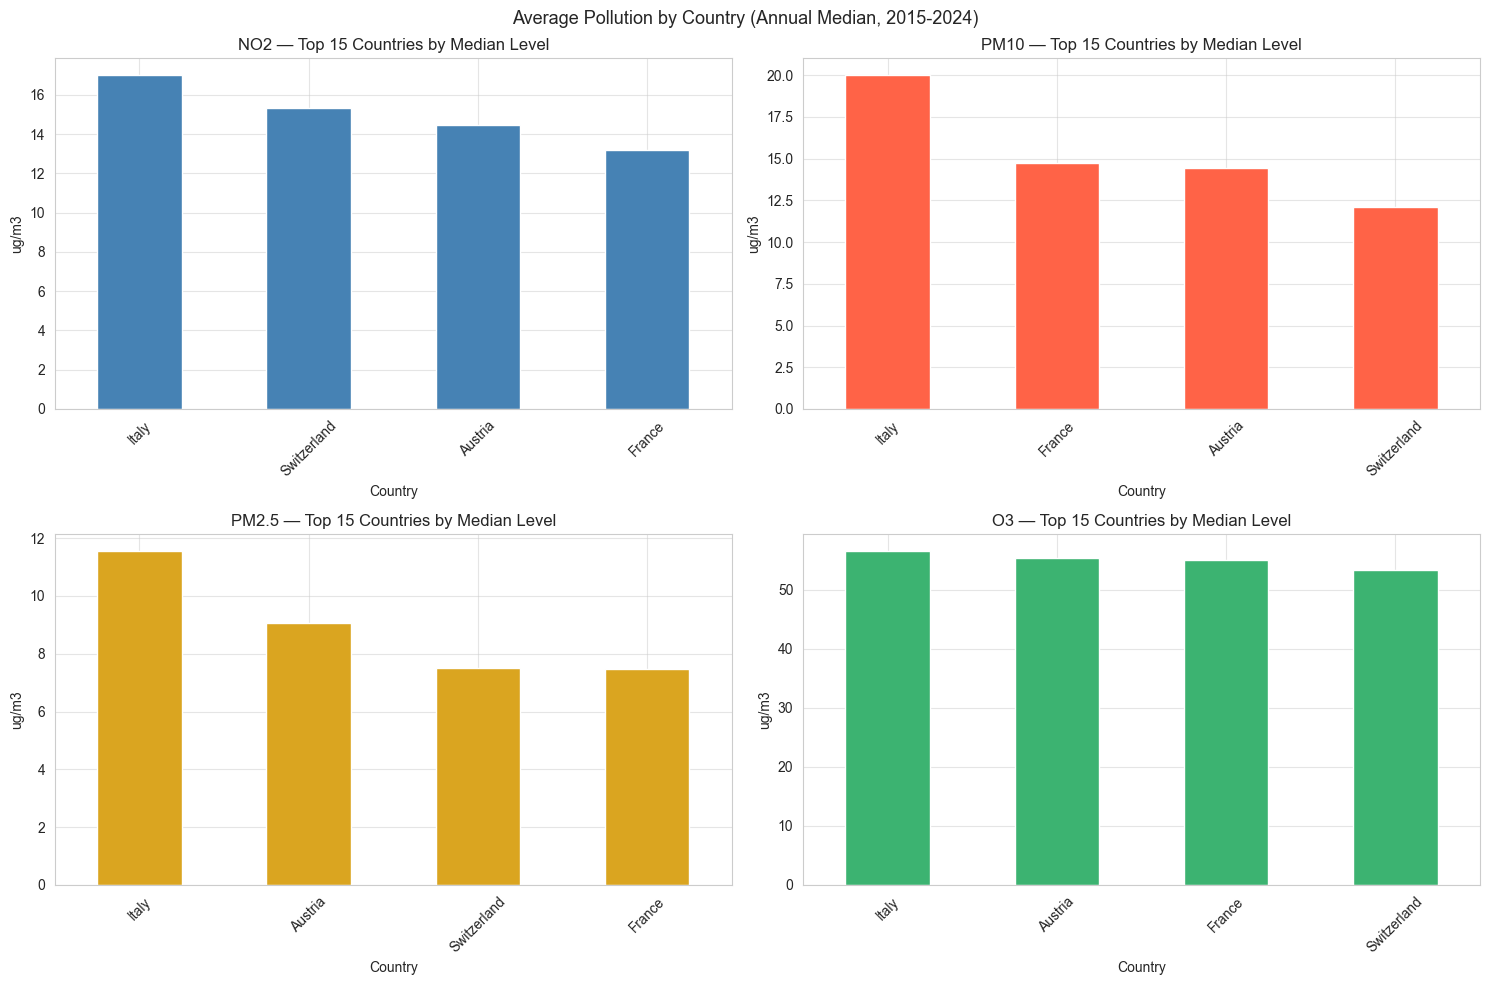

In [134]:
# Comparison between Italy, Switzerland, Austria, France
combined = pd.concat([df_focus, df_compare_focus], ignore_index=True)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, (pollutant, color) in enumerate(zip(focus_pollutants, colors)):
    sub = combined[combined['Air Pollutant'] == pollutant]
    country_median = (
        sub.groupby('Country')['Air Pollution Level']
        .median()
        .sort_values(ascending=False)
        .head(15)
    )
    country_median.plot(kind='bar', ax=axes[i], color=color, edgecolor='white')
    axes[i].set_title(f'{pollutant} — Top 15 Countries by Median Level')
    axes[i].set_ylabel('ug/m3')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Average Pollution by Country (Annual Median, 2015-2024)', fontsize=13)
plt.tight_layout()
plt.savefig("images/average_pollution_by_country.png", dpi=300)
plt.show()


## Top polluted cities

In [135]:
print("Unique cities in full df:", df["City"].nunique())
print("Unique cities in focus:", df_focus["City"].nunique())

Unique cities in full df: 461
Unique cities in focus: 444


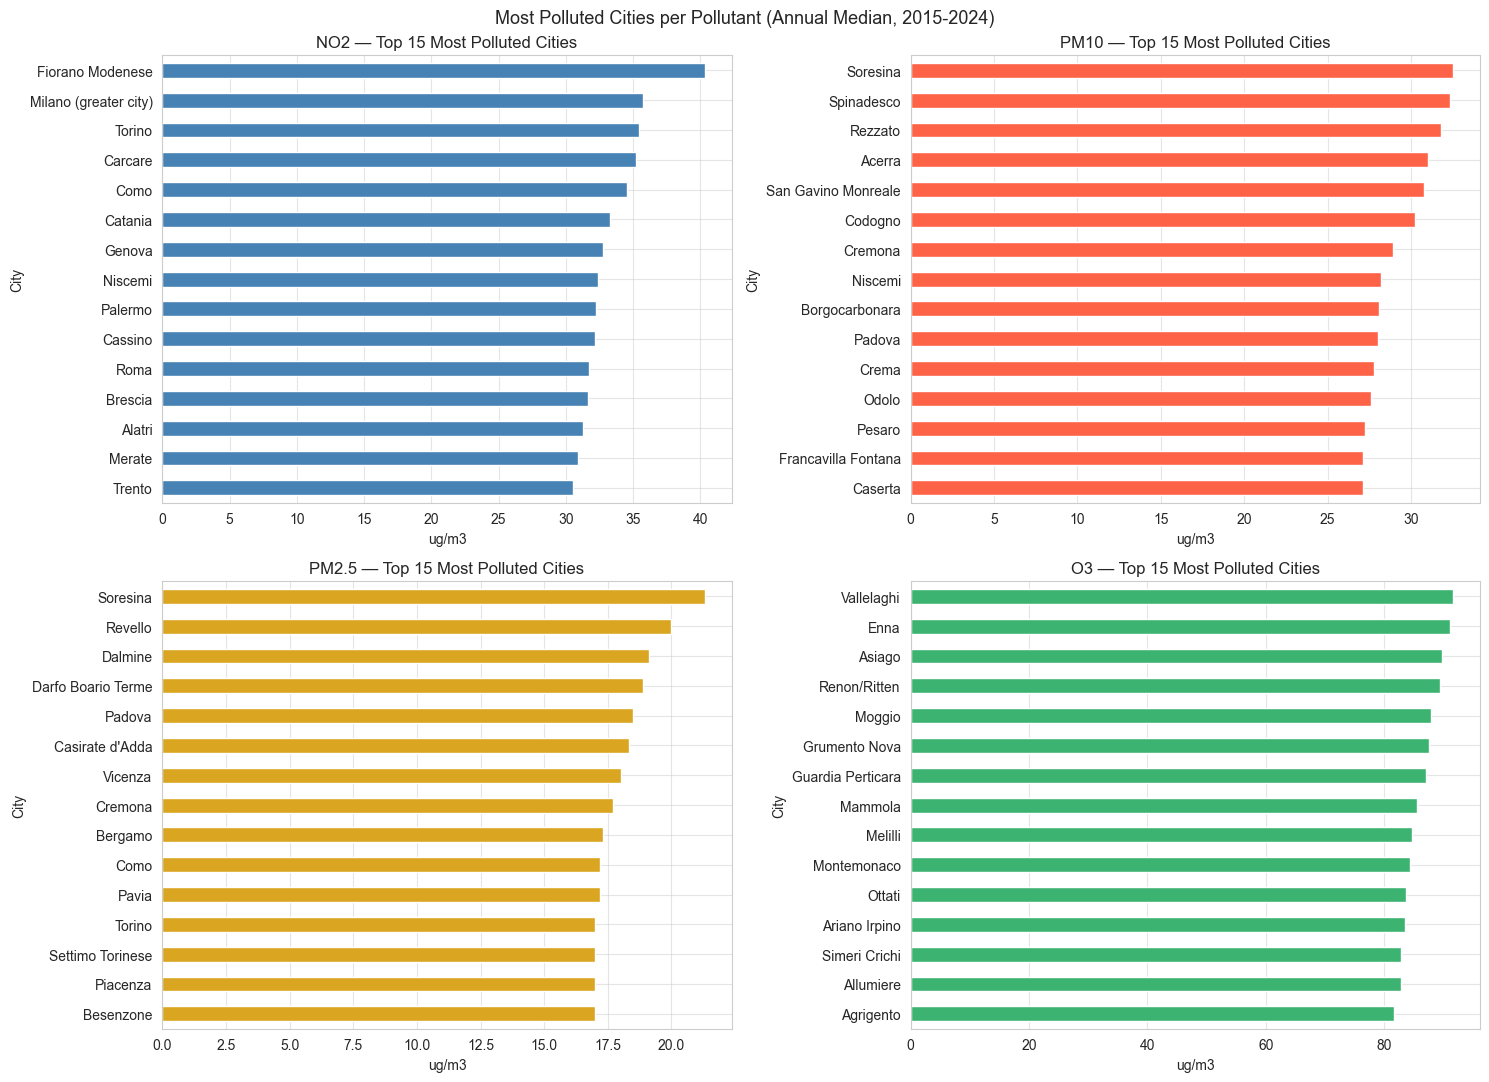

In [136]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()

for i, (pollutant, color) in enumerate(zip(focus_pollutants, colors)):
    sub = df_focus[
        (df_focus['Air Pollutant'] == pollutant) &
        (df_focus['City'].notna())
    ]

    # Robust city statistics
    city_stats = (
        sub.groupby('City')['Air Pollution Level']
        .agg(['median', 'count'])
    )

    # Require minimum number of observations per city
    city_stats = city_stats[city_stats['count'] >= 5]

    city_median = (
        city_stats['median']
        .sort_values(ascending=False)
        .head(15)
    )

    city_median.plot(kind='barh', ax=axes[i], color=color, edgecolor='white')
    axes[i].set_title(f'{pollutant} — Top 15 Most Polluted Cities')
    axes[i].set_xlabel('ug/m3')
    axes[i].invert_yaxis()

plt.suptitle('Most Polluted Cities per Pollutant (Annual Median, 2015-2024)', fontsize=13)
plt.tight_layout()
plt.savefig("images/most_polluted_cities.png", dpi=300)
plt.show()

## Station type and area comparison

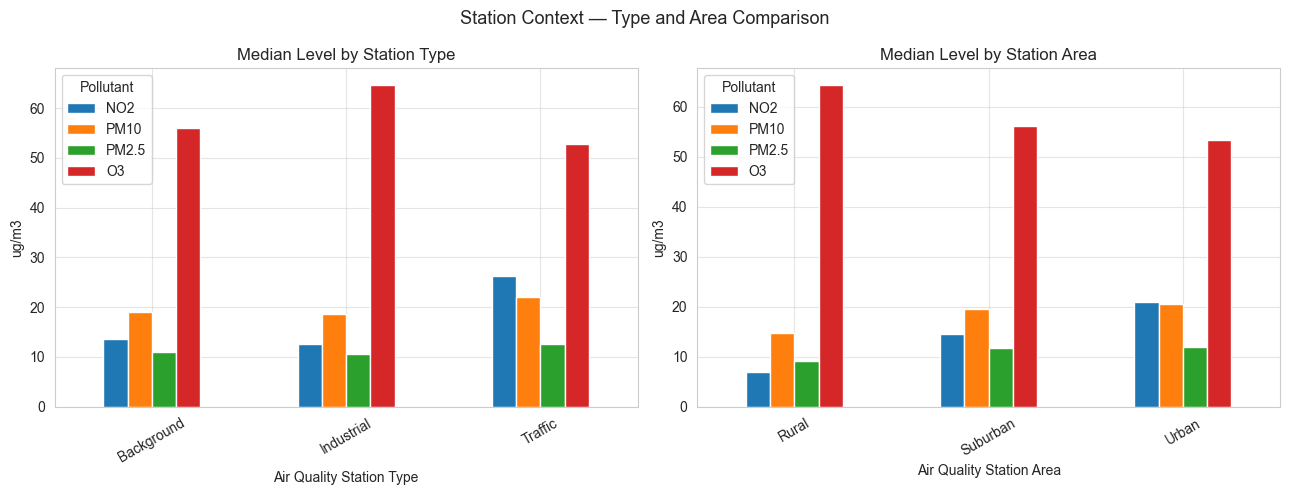

In [137]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# By station type (Traffic, Background, Industrial ...)
type_median = (
    df_focus.groupby(['Air Quality Station Type', 'Air Pollutant'])['Air Pollution Level']
    .median()
    .reset_index()
)
type_pivot = type_median.pivot(index='Air Quality Station Type',
                                columns='Air Pollutant',
                                values='Air Pollution Level')
type_pivot[focus_pollutants].plot(kind='bar', ax=axes[0], edgecolor='white')
axes[0].set_title('Median Level by Station Type')
axes[0].set_ylabel('ug/m3')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Pollutant')

# By station area (Urban, Suburban, Rural ...)
area_median = (
    df_focus.groupby(['Air Quality Station Area', 'Air Pollutant'])['Air Pollution Level']
    .median()
    .reset_index()
)
area_pivot = area_median.pivot(index='Air Quality Station Area',
                                columns='Air Pollutant',
                                values='Air Pollution Level')
area_pivot[focus_pollutants].plot(kind='bar', ax=axes[1], edgecolor='white')
axes[1].set_title('Median Level by Station Area')
axes[1].set_ylabel('ug/m3')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Pollutant')

plt.suptitle('Station Context — Type and Area Comparison', fontsize=13)
plt.tight_layout()
plt.savefig("images/station_context.png", dpi=300)
plt.show()

## Secondary Pollutants by Station Context

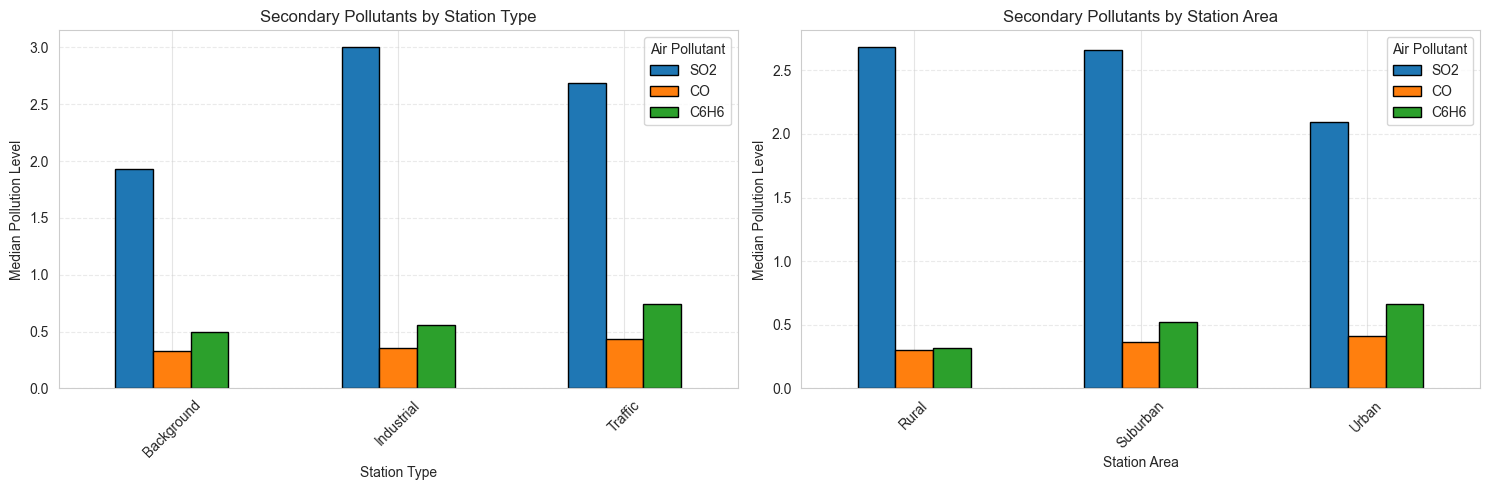

In [138]:
# Secondary pollutants by station context
secondary_subset = df_extended[
    df_extended["Air Pollutant"].isin(secondary_pollutants)
].copy()

# Median pollution by station type
type_median_ext = (
    secondary_subset
    .groupby(["Air Quality Station Type", "Air Pollutant"])["Air Pollution Level"]
    .median()
    .reset_index()
)

type_pivot_ext = type_median_ext.pivot(
    index="Air Quality Station Type",
    columns="Air Pollutant",
    values="Air Pollution Level"
)

# Median pollution by station area
area_median_ext = (
    secondary_subset
    .groupby(["Air Quality Station Area", "Air Pollutant"])["Air Pollution Level"]
    .median()
    .reset_index()
)

area_pivot_ext = area_median_ext.pivot(
    index="Air Quality Station Area",
    columns="Air Pollutant",
    values="Air Pollution Level"
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot by station type
type_pivot_ext[secondary_pollutants].plot(
    kind="bar",
    ax=axes[0],
    edgecolor="black"
)
axes[0].set_title("Secondary Pollutants by Station Type")
axes[0].set_ylabel("Median Pollution Level")
axes[0].set_xlabel("Station Type")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

# Plot by station area
area_pivot_ext[secondary_pollutants].plot(
    kind="bar",
    ax=axes[1],
    edgecolor="black"
)
axes[1].set_title("Secondary Pollutants by Station Area")
axes[1].set_ylabel("Median Pollution Level")
axes[1].set_xlabel("Station Area")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("images/secondary_by_station.png", dpi=300)
plt.show()

## Conclusion: Business Insight

Key spatial findings:

- Pollution is not evenly distributed. A small number of countries and cities drive the European average significantly upward.
- Traffic stations consistently record higher NO2 than Background stations. This directly reflects vehicle emissions and validates the monitoring approach.
- Urban areas show systematically higher levels than suburban or rural ones. This is the scientific basis for urban clean air zones.
- The city ranking gives us a hotspot map of where the air quality problem is concentrated — these cities should be the priority for both policy action and model validation.
- Secondary pollutants vary across monitoring contexts. Industrial stations show the highest SO₂ levels, while traffic and urban areas display higher CO and C6H6 concentrations. These patterns support their links to industrial combustion and vehicle emissions, helping identify potential emission sources for future modeling.
- Note: CO concentrations are measured in mg/m³ while SO₂ and C6H6 are measured in µg/m³. The comparison focuses on relative differences across station contexts rather than absolute magnitudes.

---

---
# Correlation and Feature Relationships

*Why this step?*

Correlation analysis answers:

- Do pollutants co-occur at the same stations? If NO2 is high, is PM10 also high?
- Is there a relationship between data quality (coverage) and reported pollution levels?
- Which variables carry information useful for future modeling?

To compare pollutants per station, we reshape the data so each row is one station-year
and each pollutant becomes its own column. This only works because we fixed one aggregation type (annual median).

Note on leakage: Data Coverage is a reporting-time variable studied here only for quality assessment.

## Reshaping data

In [139]:
# One row per station-year, pollutants as columns
pivot_corr = (
    df_focus
    .groupby(['Air Quality Station EoI Code', 'Year', 'Air Pollutant'])['Air Pollution Level']
    .median()
    .unstack('Air Pollutant')
    .reset_index()
)

# Only keep the focus pollutants that actually exist in this table
available = [p for p in focus_pollutants if p in pivot_corr.columns]

corr_matrix = pivot_corr[available].corr()
print('Correlation matrix between pollutants at the same station-year:')
print(corr_matrix.round(3))

Correlation matrix between pollutants at the same station-year:
Air Pollutant    NO2   PM10  PM2.5     O3
Air Pollutant                            
NO2            1.000  0.595  0.553 -0.585
PM10           0.595  1.000  0.799 -0.534
PM2.5          0.553  0.799  1.000 -0.544
O3            -0.585 -0.534 -0.544  1.000


## Correlation Heatmap

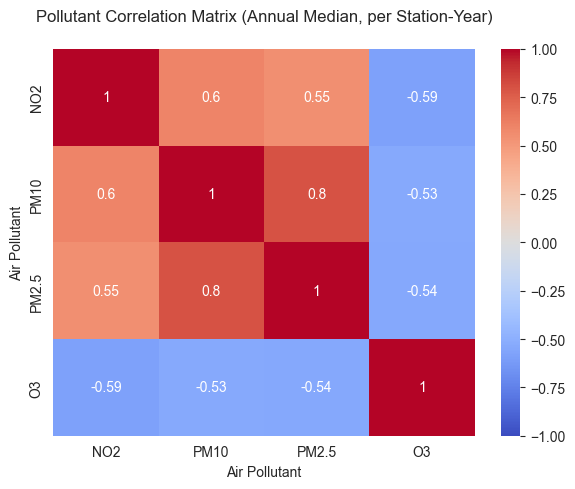

In [140]:
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Pollutant Correlation Matrix (Annual Median, per Station-Year)', pad=20)
plt.tight_layout()
plt.savefig("images/correlation_matrix.png", dpi=300)
plt.show()

## Exploratory Correlation Across All Selected Pollutants

Exploratory correlation matrix across all selected pollutants:
Air Pollutant    NO2   PM10  PM2.5     O3    SO2     CO   C6H6
Air Pollutant                                                 
NO2            1.000  0.595  0.553 -0.585  0.197  0.471  0.532
PM10           0.595  1.000  0.799 -0.534  0.096  0.243  0.296
PM2.5          0.553  0.799  1.000 -0.544  0.119  0.267  0.239
O3            -0.585 -0.534 -0.544  1.000  0.208 -0.043 -0.244
SO2            0.197  0.096  0.119  0.208  1.000  0.343  0.128
CO             0.471  0.243  0.267 -0.043  0.343  1.000  0.431
C6H6           0.532  0.296  0.239 -0.244  0.128  0.431  1.000


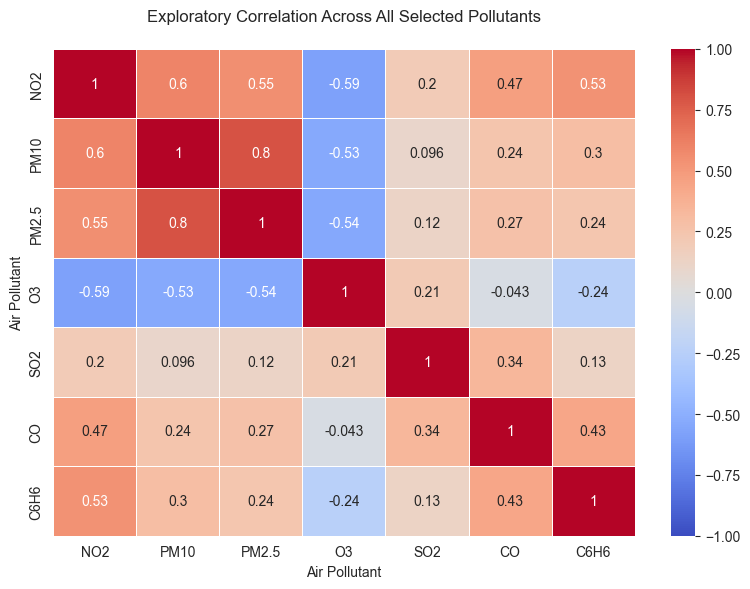

In [141]:
# Exploratory correlation across all selected pollutants

pivot_corr_ext = (
    df_extended
    .groupby(['Air Quality Station EoI Code', 'Year', 'Air Pollutant'])['Air Pollution Level']
    .median()
    .unstack('Air Pollutant')
    .reset_index()
)

# Keep only pollutants that are actually present
available_ext = [p for p in all_pollutants if p in pivot_corr_ext.columns]

corr_matrix_ext = pivot_corr_ext[available_ext].corr()

print("Exploratory correlation matrix across all selected pollutants:")
print(corr_matrix_ext.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix_ext,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title('Exploratory Correlation Across All Selected Pollutants', pad=20)
plt.tight_layout()
plt.savefig("images/extended_correlation_matrix.png", dpi=300)
plt.show()

## Pollutant Pairs: Scatter plots

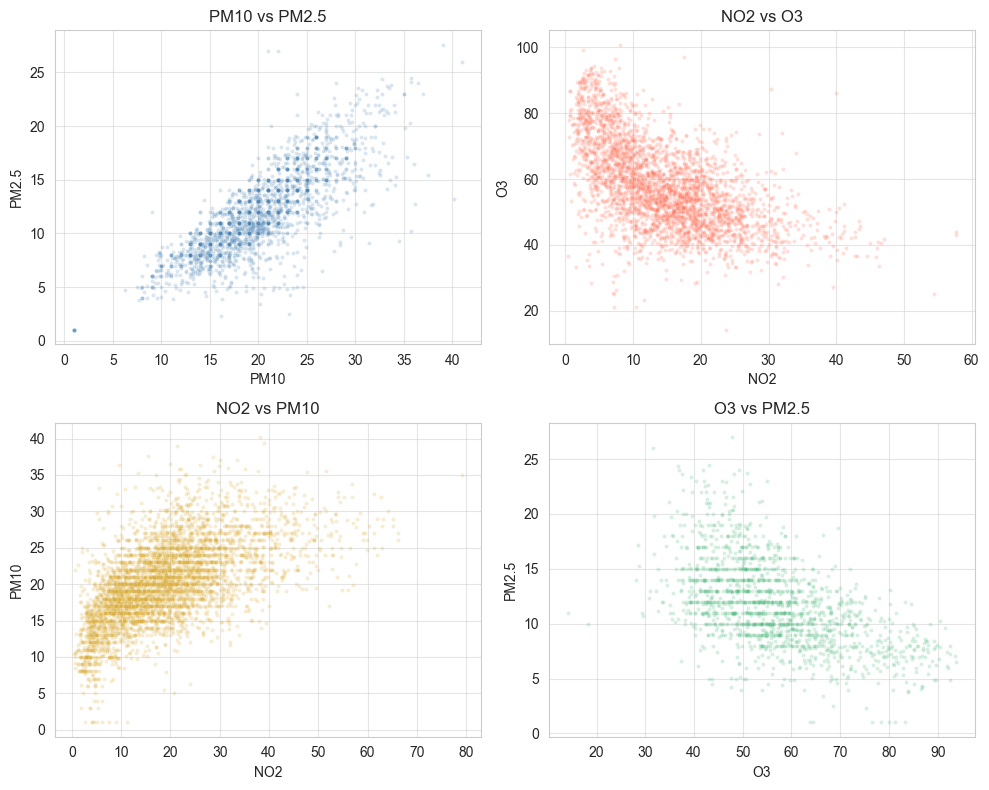

In [142]:
pairs = [('PM10', 'PM2.5'), ('NO2', 'O3'), ('NO2', 'PM10'), ('O3', 'PM2.5')]

# Unstack pollutants into columns for seaborn
df_scatter = df_focus.pivot_table(
    index=['Air Quality Station EoI Code', 'Year'],
    columns='Air Pollutant',
    values='Air Pollution Level',
    aggfunc='median'
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, (a, b) in enumerate(pairs):
    # Drop rows where either pollutant is missing to avoid seaborn errors
    plot_df = df_scatter.dropna(subset=[a, b])
    
    sns.scatterplot(data=plot_df, x=a, y=b, alpha=0.2, s=8, color=colors[i], ax=axes[i])
    axes[i].set_title(f"{a} vs {b}")

plt.tight_layout()
plt.savefig("images/pairs_pollutants_scatterplot.png", dpi=300)
plt.show()


## Effect of Data Coverage level

Coverage Bucket
below 50%    10.854
50-75%       15.308
75-90%       15.678
above 90%    17.200
Name: Air Pollution Level, dtype: float64


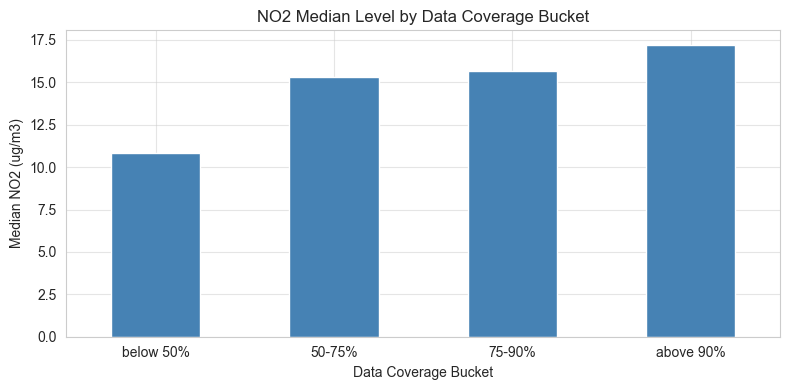

In [143]:
# Does data coverage level affect the recorded pollution value?
# (Leakage note: studied here for quality purposes only — not a future feature)

df_no2 = df_focus[df_focus['Air Pollutant'] == 'NO2'][['Data Coverage', 'Air Pollution Level']].dropna()
df_no2['Coverage Bucket'] = pd.cut(
    df_no2['Data Coverage'],
    bins=[0, 50, 75, 90, 100],
    labels=['below 50%', '50-75%', '75-90%', 'above 90%']
)

bucket_median = df_no2.groupby('Coverage Bucket', observed=True)['Air Pollution Level'].median()
bucket_median.to_csv("images/data_coverage_bucket_no2_median.csv")
print(bucket_median)

bucket_median.plot(kind='bar', figsize=(8, 4), color='steelblue', edgecolor='white')
plt.title('NO2 Median Level by Data Coverage Bucket')
plt.ylabel('Median NO2 (ug/m3)')
plt.xlabel('Data Coverage Bucket')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("images/data_coverage_bucket_no2_median.png", dpi=300)
plt.show()

## Conclusion: Business Insight

Key correlation findings:

- NO2 and PM10/PM2.5 tend to co-occur at the same stations. These pollutants share sources: combustion engines and industrial processes. Targeting one source (e.g., reducing car traffic) will tend to improve multiple pollutants simultaneously.
- If correlations are strong, a single feature set could be used to predict multiple pollutant targets without building entirely separate models.
- The coverage-vs-level check is a data quality signal. If stations with low coverage report systematically lower pollution, they may be missing peak episodes (e.g., winter heating). This would bias the dataset and must be addressed in the cleaning step.
- The expanded correlation analysis highlights moderate links between traffic-related pollutants (NO2, CO, C6H6), while O3 shows negative correlations with combustion pollutants, reflecting its secondary atmospheric formation.

---

---
# Key Findings and Next Steps

While the core analysis focuses on four major pollutants (NO2, PM10, PM2.5, O3), three additional pollutants (SO2, CO, and C6H6) were explored to provide further insight into emission sources.
These pollutants are associated with industrial combustion (SO2), incomplete fuel combustion from vehicles (CO), and fuel evaporation or traffic-related emissions (C6H6).
Their inclusion helps connect pollutant patterns with potential emission drivers.

---

## Data Quality Summary — Cleaning Agenda for Step 3

| Issue | What We Observed | Action Needed in Step 3 |
|-------|-----------------|-------------------------|
| Missing values | Some columns have significant gaps | Drop or impute per column |
| Low data coverage | Some stations measured less than 75% of the year | Filter or flag as low-quality |
| Unverified records | A fraction of rows are not officially validated | Filter to Verification equal to 1 |
| Multiple aggregation types | Rows mix medians, maxima, percentiles | Fix one aggregation type per analysis |
| City name padding | Trailing whitespace in City column | Apply str.strip() |
| Extreme outliers | Right-skewed distributions with very high values | Cap or log-transform before modeling |

---

## Business Insights Summary

| # | Insight | Business Implication |
|---|---------|---------------------|
| 1 | Distributions are right-skewed — most stations are moderate, a few are severe hotspots | Hotspot-targeted interventions deliver the biggest health impact per euro spent |
| 2 | Visible pollution drop in 2020 coinciding with COVID lockdowns | Human activity is the primary driver — structural change can and does reduce pollution |
| 3 | Long-term downward trend from 2015 (to be confirmed after cleaning) | EU Clean Air policies show results, but progress is uneven across countries |
| 4 | Traffic stations record significantly higher NO2 than Background stations | Vehicle emissions are the dominant urban source of NO2 |
| 5 | Urban areas consistently more polluted than rural areas | Dense cities are the priority zones for public health intervention |
| 6 | NO2, PM10, and PM2.5 are positively correlated at the same station | A single policy or model targeting combustion sources addresses multiple pollutants |

---

## Recommended Modeling Direction — Step 4

Two modeling approaches are feasible based on the EDA:

Option A — Regression: predict the annual median pollution level for a given station and year.

Option B — Classification: predict whether a station will exceed EU regulatory limits in a given year.
- NO2 annual limit: 40 ug/m3
- PM10 annual limit: 40 ug/m3
- PM2.5 annual limit: 25 ug/m3

Recommended starting point: Option B (classification). It produces a clear binary output that is directly actionable for policy reporting, and it is simpler to evaluate.

## Data Leakage Prevention for Step 4

The following columns must not be used as model features:

- Data Coverage: only available after the measurement period ends, not at prediction time
- Verification: a post-hoc validation status, not a prediction-time variable
- Calculation Time: when the statistic was computed, not a real-world predictor
- Air Pollution Level: if predicting whether a limit is exceeded, the label is derived from this column — using it as a feature would be direct leakage

---

Step 2 (Preliminary Analysis) finished.
Next: Step 3 — Data Cleaning and Transformation.